 Projet Python — Analyse et Prédiction du Taux de Masse Graisseuse

Objectifs du projet
Ce projet consiste à :
1. Charger et nettoyer les données
2. Réaliser une analyse exploratoire (EDA)
3. Construire des indicateurs et catégories
4. Créer un modèle de Machine Learning pour prédire le BodyFat


In [44]:
# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
# Chargement du dataset

df = pd.read_csv(
    r"C:\Users\mdiallo37\Desktop\Projet_linkedin\bodyfat.csv",
    sep=",",
    encoding="latin1"
)

# Affichage des premières lignes
df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [48]:
# Statistiques descriptives

df.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


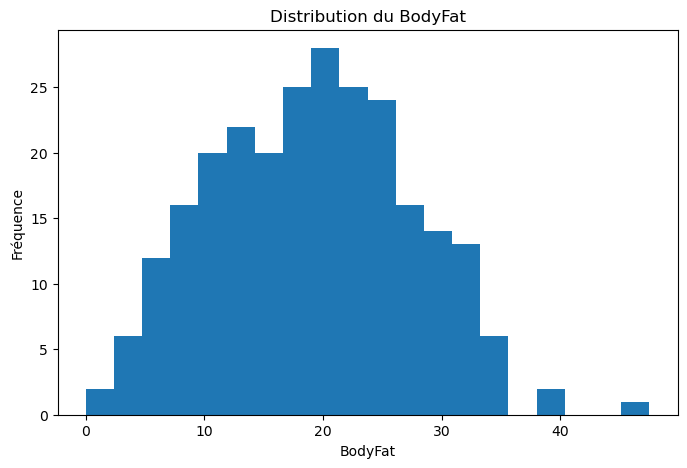

In [50]:
# 2. Analyse Exploratoire des Données (EDA)
# Histogramme du BodyFat

plt.figure(figsize=(8,5))
plt.hist(df['BodyFat'], bins=20)
plt.title('Distribution du BodyFat')
plt.xlabel('BodyFat')
plt.ylabel('Fréquence')
plt.show()

In [54]:
# Histogramme de l'âge

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=15)
plt.title('Distribution de l\\'Age')
plt.xlabel('Age')
plt.ylabel('Fréquence')
plt.show()

SyntaxError: unterminated string literal (detected at line 5) (2190181964.py, line 5)

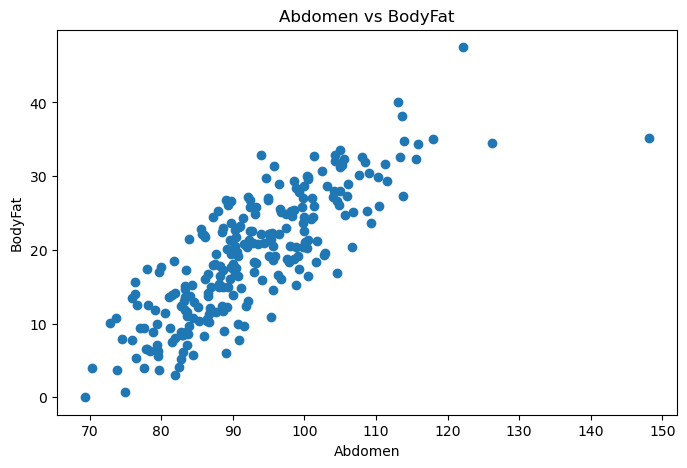

In [56]:
# Relation entre Abdomen et BodyFat

plt.figure(figsize=(8,5))
plt.scatter(df['Abdomen'], df['BodyFat'])
plt.title('Abdomen vs BodyFat')
plt.xlabel('Abdomen')
plt.ylabel('BodyFat')
plt.show()

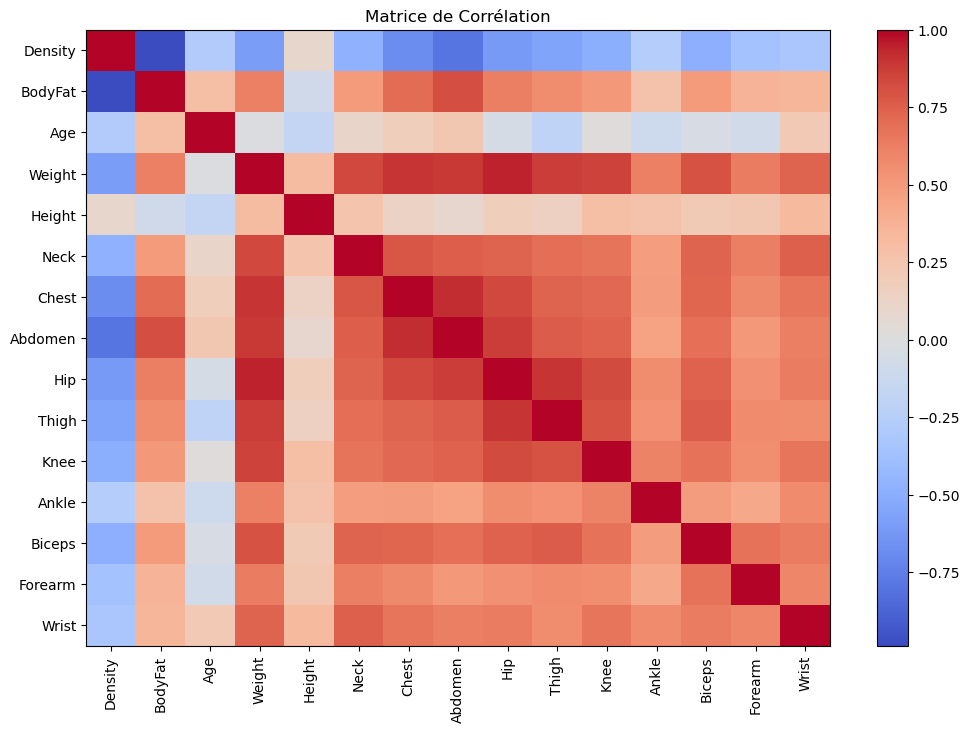

In [58]:
# Corrélations

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Matrice de Corrélation')
plt.show()

In [60]:
# Variables les plus corrélées avec BodyFat

corr_bodyfat = corr['BodyFat'].sort_values(ascending=False)
print(corr_bodyfat)

BodyFat    1.000000
Abdomen    0.813432
Chest      0.702620
Hip        0.625201
Weight     0.612414
Thigh      0.559608
Knee       0.508665
Biceps     0.493271
Neck       0.490592
Forearm    0.361387
Wrist      0.346575
Age        0.291458
Ankle      0.265970
Height    -0.089495
Density   -0.987782
Name: BodyFat, dtype: float64


In [62]:
# Création de catégories BodyFat

def categorie_bodyfat(x):
    if x < 10:
        return 'Athlétique'
    elif x < 20:
        return 'Normal'
    elif x < 25:
        return 'Surpoids'
    else:
        return 'Obésité'

df['Categorie'] = df['BodyFat'].apply(categorie_bodyfat)

df[['BodyFat', 'Categorie']].head()

,BodyFat,Categorie
0,12.3,Normal
1,6.1,Athlétique
2,25.3,Obésité
3,10.4,Normal
4,28.7,Obésité


In [64]:
# Répartition des catégories

df['Categorie'].value_counts()

Categorie
Normal        93
Obésité       66
Surpoids      54
Athlétique    39
Name: count, dtype: int64

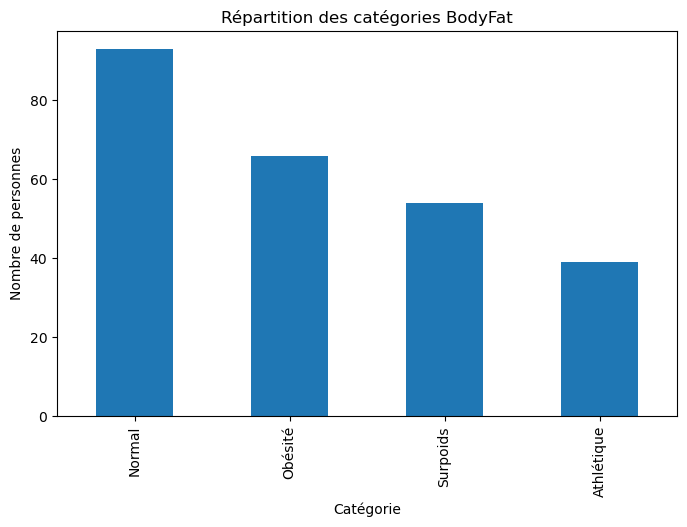

In [66]:
# Visualisation des catégories

df['Categorie'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title('Répartition des catégories BodyFat')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de personnes')
plt.show()

In [70]:
# Création de l'IMC

# Conversion du poids en kg
df['Weight_kg'] = df['Weight'] * 0.453592

# Conversion de la taille en mètres
df['Height_m'] = df['Height'] * 0.0254

# Calcul BMI
df['IMC'] = df['Weight_kg'] / (df['Height_m'] ** 2)

df[['IMC']].head()

,IMC
0,23.626779
1,23.334338
2,24.668737
3,24.883227
4,25.517358


In [74]:
# 4. Machine Learning — Prédiction du BodyFat
"""))

cells.append(new_code_cell("""
# Variables explicatives et variable cible

X = df.drop(columns=['BodyFat', 'Categorie'])
y = df['BodyFat']
# Séparation train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
# Modèle Régression Linéaire

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred_lr))
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 Score : 0.9914587292828354
MAE : 0.4638489212612783
RMSE : 0.6303359650854014


In [84]:
# Modèle du Random forest

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred_rf))
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score : 0.9990655741672073
MAE : 0.14625490196078464
RMSE : 0.20848905552692903


In [80]:
# Importance des variables

importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Variable,Importance
0,Density,0.980141
15,Height_m,0.002878
6,Abdomen,0.002655
9,Knee,0.002419
3,Height,0.001814
2,Weight,0.001376
5,Chest,0.001344
14,Weight_kg,0.001159
4,Neck,0.001021
7,Hip,0.000958


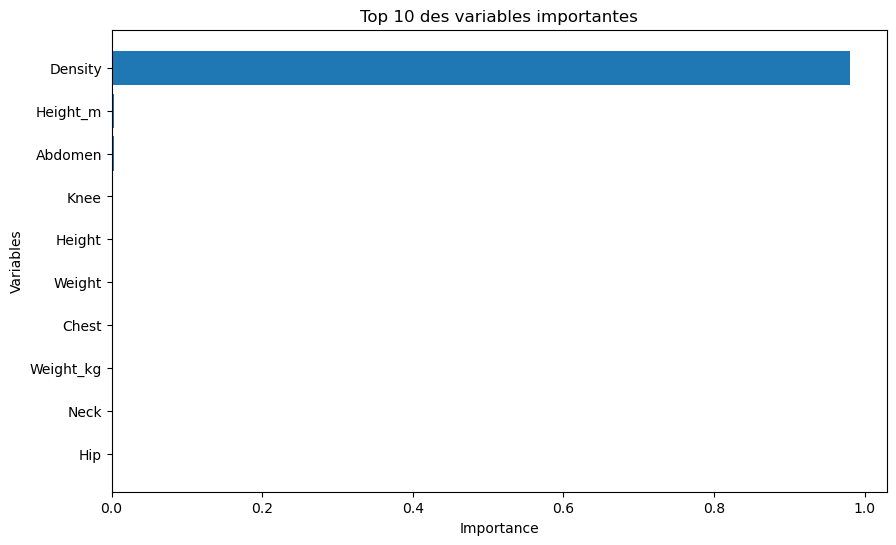

In [82]:
# Visualisation des variables importantes

top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Variable'], top10['Importance'])

plt.title('Top 10 des variables importantes')
plt.xlabel('Importance')
plt.ylabel('Variables')

plt.gca().invert_yaxis()
plt.show()